# Notebook 1: DataCo Smart Supply Chain — Exploratory Data Analysis and Feature Engineering

**Dataset**: DataCo Smart Supply Chain for Big Data Analysis (Kaggle)
https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis

**Run this notebook first.** Saves `X_processed.npy`, `y_processed.npy`, `feature_names.npy` to `../data/`.

| Column | Role |
|---|---|
| `order date (DateOrders)` | Datetime — temporal features + row ordering |
| `Days for shipment (scheduled)`, `Order Item Discount`, `Order Item Discount Rate`, `Order Item Product Price`, `Order Item Quantity`, `Latitude`, `Longitude` | 7 numeric features |
| `Type`, `Shipping Mode`, `Customer Segment`, `Market`, `Delivery Status`, `Department Name` | Categorical → one-hot encoded (25 dummies) |
| `Order Item Total` | **Excluded** — ≈ Sales + Discount (r=0.99, target leakage) |
| `Sales per customer` | **Excluded** — aggregation of target (r=0.99, target leakage) |
| `Benefit per order`, `Order Profit Per Order`, `Order Item Profit Ratio` | **Excluded** — algebraically derived from Sales |
| `Product Price` | **Excluded** — identical to `Order Item Product Price` (diff=0) |
| `Sales` | **Target** — order-item revenue in USD |

## Dataset Download

### Option A — Kaggle API
```bash
pip install kaggle
# Place ~/.kaggle/kaggle.json (from https://www.kaggle.com/settings/account)
kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis \
    -p ../data/ --unzip
# Rename to DataCoSupplyChainDataset.csv if needed
```

### Option B — Manual
1. Download from: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
2. Place the CSV at `../data/DataCoSupplyChainDataset.csv`

### Option C — Direct URL (if available)
Check Kaggle for direct download links.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from experiments.data_pipeline import (
    load_raw, engineer_features, build_design_matrix,
    DATA_PATH, TARGET_COL, LABEL_COLS, FEATURE_COLS, CAT_FEATURE_COLS, DATE_COL,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = os.path.join(os.getcwd(), "..", "data")

print(f"Data path : {DATA_PATH}")
print(f"Exists    : {os.path.exists(DATA_PATH)}")
print(f"Target    : {TARGET_COL}")
print(f"Leakage excluded : {LABEL_COLS}")
print(f"Numeric features : {FEATURE_COLS}")
print(f"Categorical features: {CAT_FEATURE_COLS}")

Data path : /Users/sarthakgarg/Desktop/UMD/MSML604/Project/msml604-convex-regression/data/DataCoSupplyChainDataset.csv
Exists    : True
Target    : Sales
Leakage excluded : {'Benefit per order', 'Order Item Total', 'Sales per customer', 'Order Item Profit Ratio', 'Order Profit Per Order'}
Numeric features : ['Days for shipment (scheduled)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Quantity', 'Latitude', 'Longitude']
Categorical features: ['Type', 'Shipping Mode', 'Customer Segment', 'Market', 'Delivery Status', 'Department Name']


---
## 1. Load Raw Data

In [2]:
df_raw = load_raw()
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape: (180519, 53)
Columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Stat

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


---
## 2. Data Types and Missing Values

In [3]:
info = pd.DataFrame({
    "dtype":       df_raw.dtypes,
    "n_missing":   df_raw.isnull().sum(),
    "pct_missing": (df_raw.isnull().mean() * 100).round(2),
    "n_unique":    df_raw.nunique(),
})
info

,dtype,n_missing,pct_missing,n_unique
Type,str,0,0.00,4
Days for shipping (real),int64,0,0.00,7
Days for shipment (scheduled),int64,0,0.00,4
Benefit per order,float64,0,0.00,21998
Sales per customer,float64,0,0.00,2927
Delivery Status,str,0,0.00,4
Late_delivery_risk,int64,0,0.00,2
Category Id,int64,0,0.00,51
Category Name,str,0,0.00,50
Customer City,str,0,0.00,563


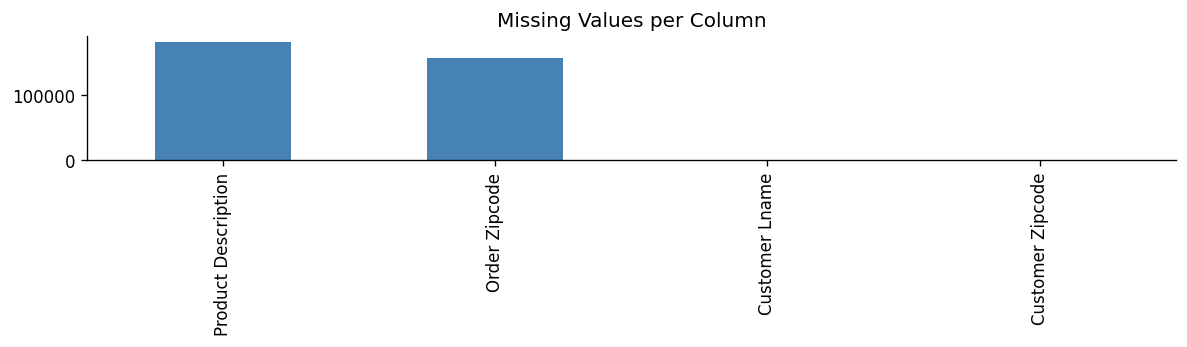

In [4]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    missing.plot(kind="bar", figsize=(10, 3), title="Missing Values per Column", color="steelblue")
    plt.tight_layout(); plt.show()
else:
    print("No missing values.")

---
## 3. Label Column Inspection (Excluded from X)

The following columns are **algebraically derived from `Sales`** and must be excluded — using them as features is target leakage:

| Column | Relationship to Sales | Correlation |
|---|---|---|
| `Order Item Total` | ≈ Sales + Discount | r = 0.99 |
| `Sales per customer` | Aggregated Sales per customer | r = 0.99 |
| `Benefit per order` | Sales − Cost | r = 0.13 (indirect) |
| `Order Profit Per Order` | Same as Benefit per order | r = 0.13 |
| `Order Item Profit Ratio` | Profit / Sales | derived |

`Product Price` is also excluded because it is **identical** to `Order Item Product Price` (difference = 0 across all rows).

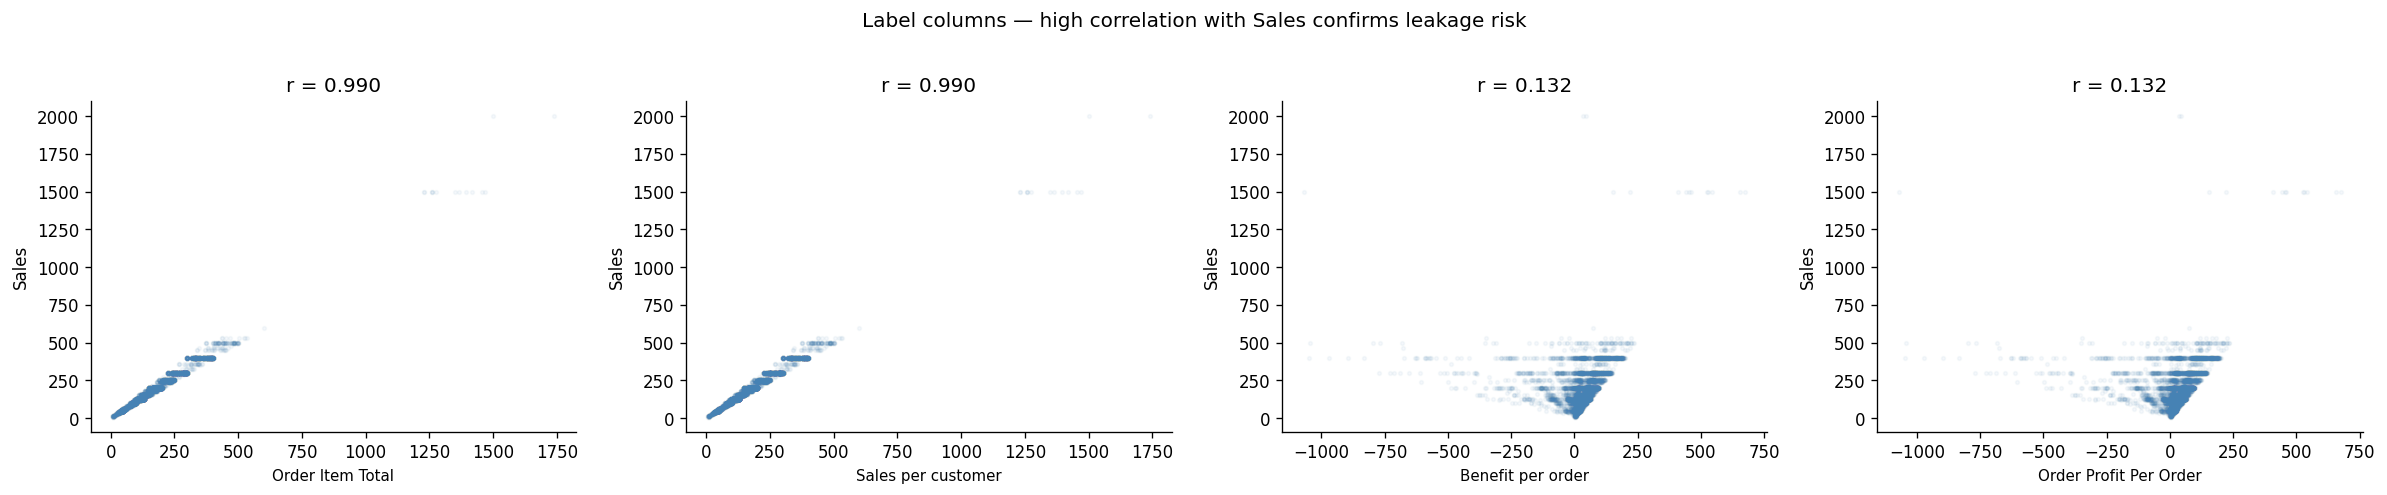


Product Price vs Order Item Product Price — max difference: 0.0
→ Identical column, one must be excluded.

Correlations with Sales:
  Order Item Total: r = 0.9897
  Sales per customer: r = 0.9897
  Benefit per order: r = 0.1318
  Order Profit Per Order: r = 0.1318


In [5]:
label_cols_in_df = [c for c in ["Order Item Total", "Sales per customer", "Benefit per order",
                                 "Order Profit Per Order"] if c in df_raw.columns]

fig, axes = plt.subplots(1, len(label_cols_in_df), figsize=(5 * len(label_cols_in_df), 4))
if len(label_cols_in_df) == 1:
    axes = [axes]

sample = df_raw.sample(min(5000, len(df_raw)), random_state=42)
for ax, col in zip(axes, label_cols_in_df):
    ax.scatter(sample[col], sample[TARGET_COL], alpha=0.05, s=5, color="steelblue")
    r = df_raw[[col, TARGET_COL]].corr().iloc[0, 1]
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(TARGET_COL)
    ax.set_title(f"r = {r:.3f}")

plt.suptitle("Label columns — high correlation with Sales confirms leakage risk", y=1.02)
plt.tight_layout()
plt.show()

# Also confirm Product Price == Order Item Product Price
diff = (df_raw["Product Price"] - df_raw["Order Item Product Price"]).abs().max()
print(f"\nProduct Price vs Order Item Product Price — max difference: {diff}")
print("→ Identical column, one must be excluded.")
print("\nCorrelations with Sales:")
for col in label_cols_in_df:
    r = df_raw[[col, TARGET_COL]].corr().iloc[0, 1]
    print(f"  {col}: r = {r:.4f}")

---
## 4. Target Variable Distribution

`Sales` is the revenue in USD for each order. We predict this using supply chain features (quantity, discount, product price, etc.).

Count : 180,519
Mean  : $203.77
Std   : $132.27
Min   : $9.99
Max   : $1999.99
Median: $199.92
Skew  : 2.8842


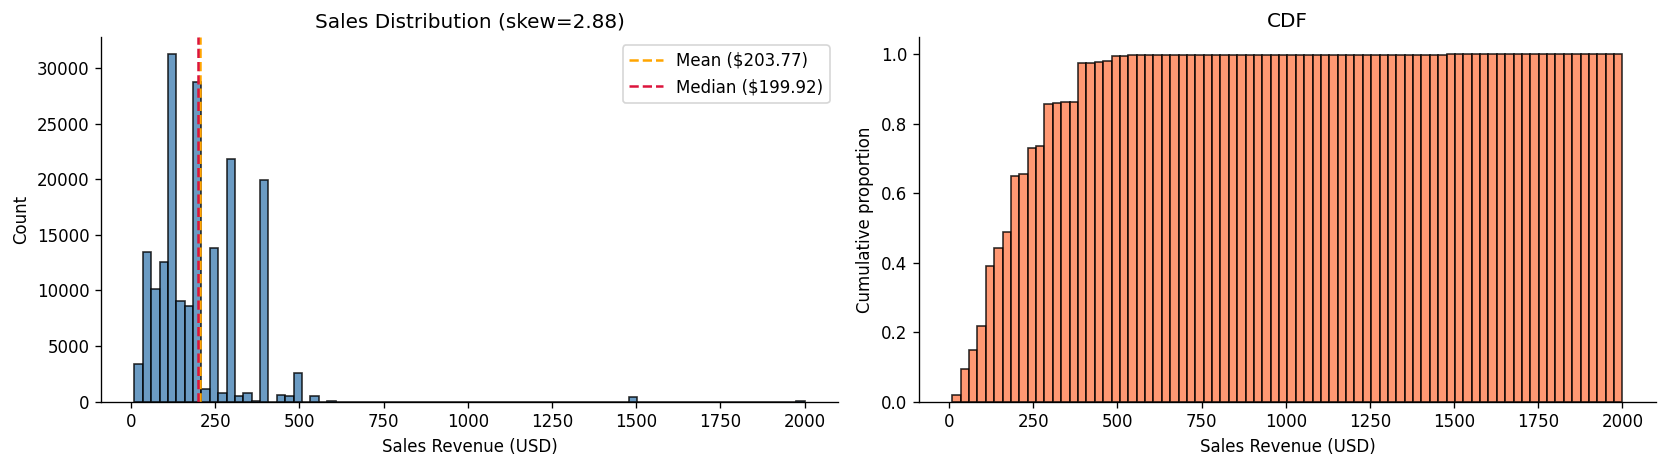

In [6]:
t = df_raw[TARGET_COL]
print(f"Count : {len(t):,}")
print(f"Mean  : ${t.mean():.2f}")
print(f"Std   : ${t.std():.2f}")
print(f"Min   : ${t.min():.2f}")
print(f"Max   : ${t.max():.2f}")
print(f"Median: ${t.median():.2f}")
print(f"Skew  : {t.skew():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(t, bins=80, edgecolor="k", alpha=0.8, color="steelblue")
axes[0].axvline(t.mean(), color="orange", ls="--", lw=1.5, label=f"Mean (${t.mean():.2f})")
axes[0].axvline(t.median(), color="crimson", ls="--", lw=1.5, label=f"Median (${t.median():.2f})")
axes[0].set_xlabel("Sales Revenue (USD)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"{TARGET_COL} Distribution (skew={t.skew():.2f})")
axes[0].legend()

axes[1].hist(t, bins=80, cumulative=True, density=True, edgecolor="k", alpha=0.8, color="coral")
axes[1].set_xlabel("Sales Revenue (USD)")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_title("CDF")

plt.tight_layout()
plt.show()

---
## 5. Raw Numeric Feature Distributions

The 7 numeric features are: `Days for shipment (scheduled)`, `Order Item Discount`, `Order Item Discount Rate`, `Order Item Product Price`, `Order Item Quantity`, `Latitude`, `Longitude`.

In [7]:
print(df_raw[FEATURE_COLS].describe().round(3).to_string())

       Days for shipment (scheduled)  Order Item Discount  Order Item Discount Rate  Order Item Product Price  Order Item Quantity    Latitude   Longitude
count                     180519.000           180519.000                180519.000                180519.000           180519.000  180519.000  180519.000
mean                           2.932               20.665                     0.102                   141.233                2.128      29.720     -84.916
std                            1.374               21.801                     0.070                   139.732                1.453       9.814      21.433
min                            0.000                0.000                     0.000                     9.990                1.000     -33.938    -158.026
25%                            2.000                5.400                     0.040                    50.000                1.000      18.265     -98.446
50%                            4.000               14.000             

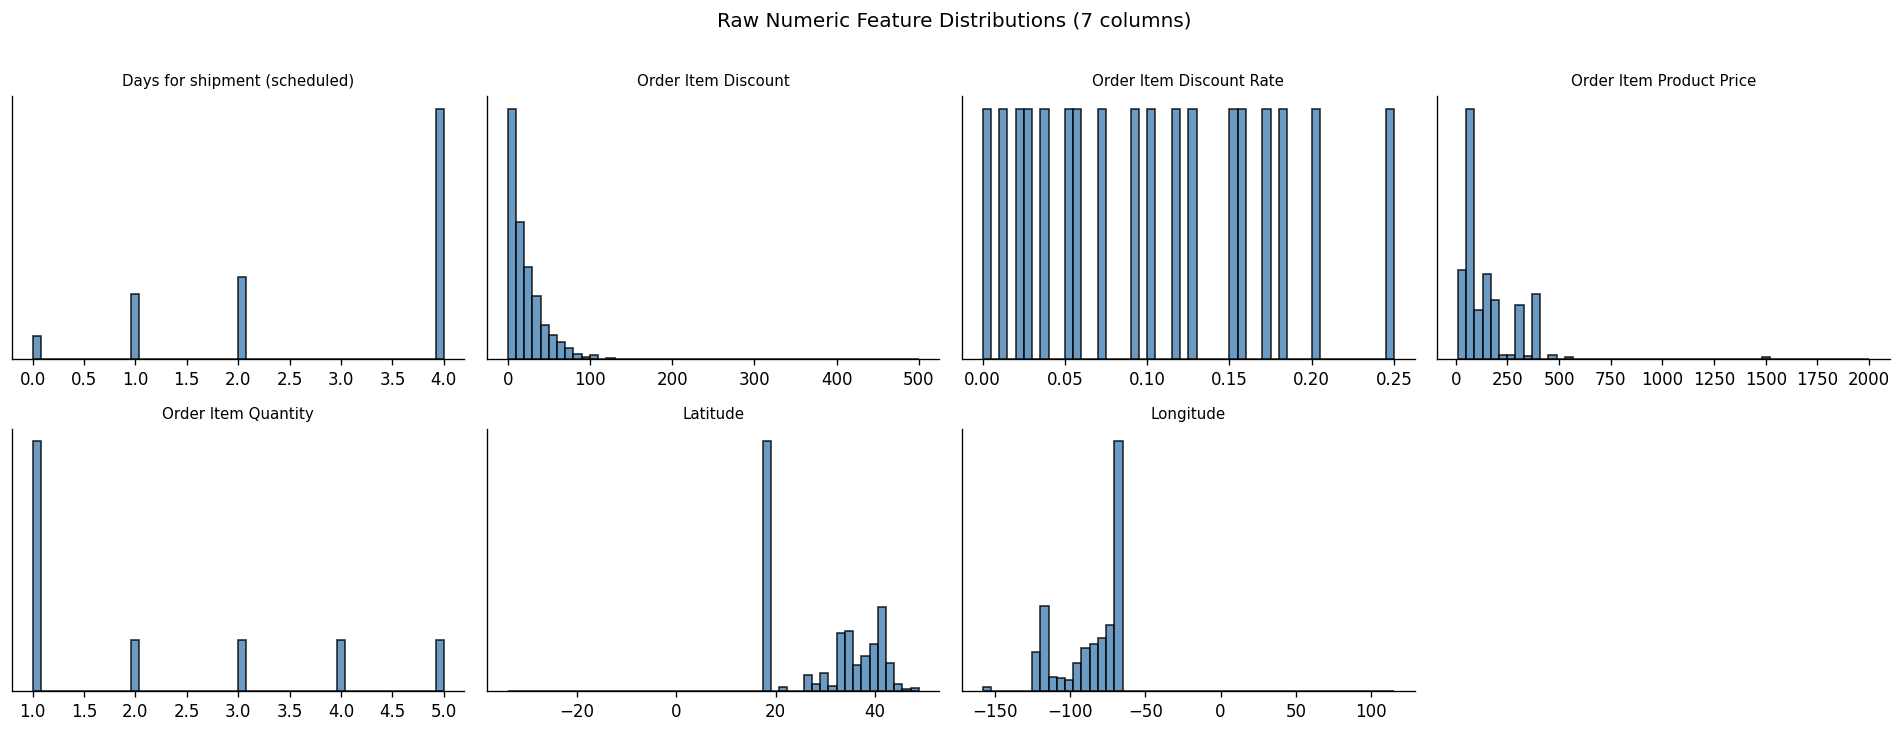

       Days for shipment (scheduled)  Order Item Discount  Order Item Discount Rate  Order Item Product Price  Order Item Quantity    Latitude   Longitude
count                     180519.000           180519.000                180519.000                180519.000           180519.000  180519.000  180519.000
mean                           2.932               20.665                     0.102                   141.233                2.128      29.720     -84.916
std                            1.374               21.801                     0.070                   139.732                1.453       9.814      21.433
min                            0.000                0.000                     0.000                     9.990                1.000     -33.938    -158.026
25%                            2.000                5.400                     0.040                    50.000                1.000      18.265     -98.446
50%                            4.000               14.000             

In [8]:
n_cols_grid = 4
n_rows_grid = (len(FEATURE_COLS) + n_cols_grid - 1) // n_cols_grid
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df_raw[col].dropna(), bins=50, edgecolor="k", alpha=0.8, color="steelblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Raw Numeric Feature Distributions ({len(FEATURE_COLS)} columns)", y=1.01)
plt.tight_layout()
plt.show()

print(df_raw[FEATURE_COLS].describe().round(3).to_string())

---
## 6. Categorical Feature Distributions

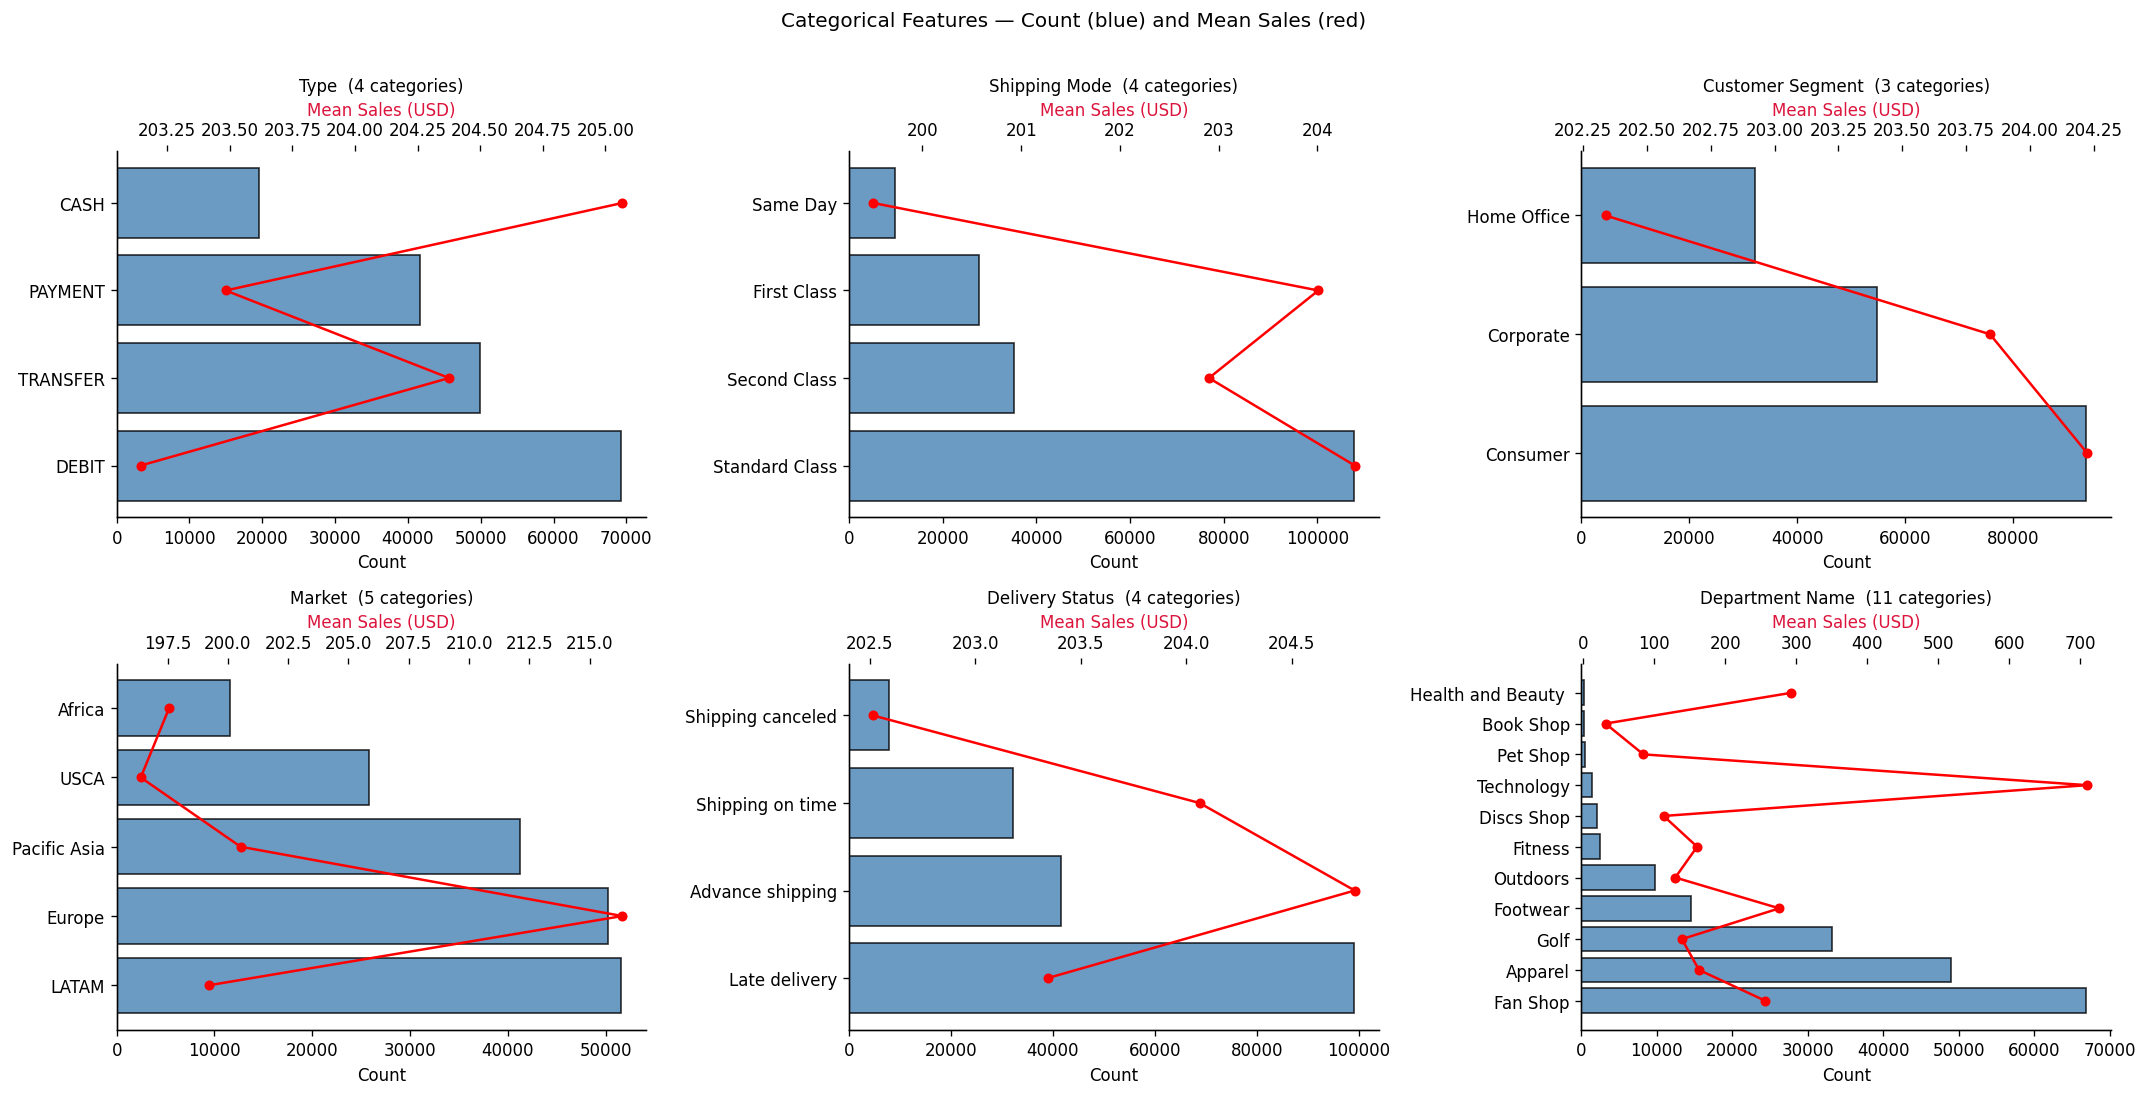

In [9]:
cats_present = [c for c in CAT_FEATURE_COLS if c in df_raw.columns]
n_cats = len(cats_present)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cats_present):
    vc = df_raw[col].value_counts()
    axes[i].barh(vc.index.astype(str), vc.values, color="steelblue", edgecolor="k", alpha=0.8)
    axes[i].set_title(f"{col}  ({df_raw[col].nunique()} categories)", fontsize=10)
    axes[i].set_xlabel("Count")
    mean_by_cat = df_raw.groupby(col)[TARGET_COL].mean().reindex(vc.index)
    ax2 = axes[i].twiny()
    ax2.plot(mean_by_cat.values, range(len(vc)), "ro-", ms=5, label="Mean Sales")
    ax2.set_xlabel("Mean Sales (USD)", color="crimson")

for j in range(n_cats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features — Count (blue) and Mean Sales (red)", y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Order Date Range and Volume

Date range: 2015-01-01 00:00:00 → 2018-01-31 23:38:00
Span: 1126 days


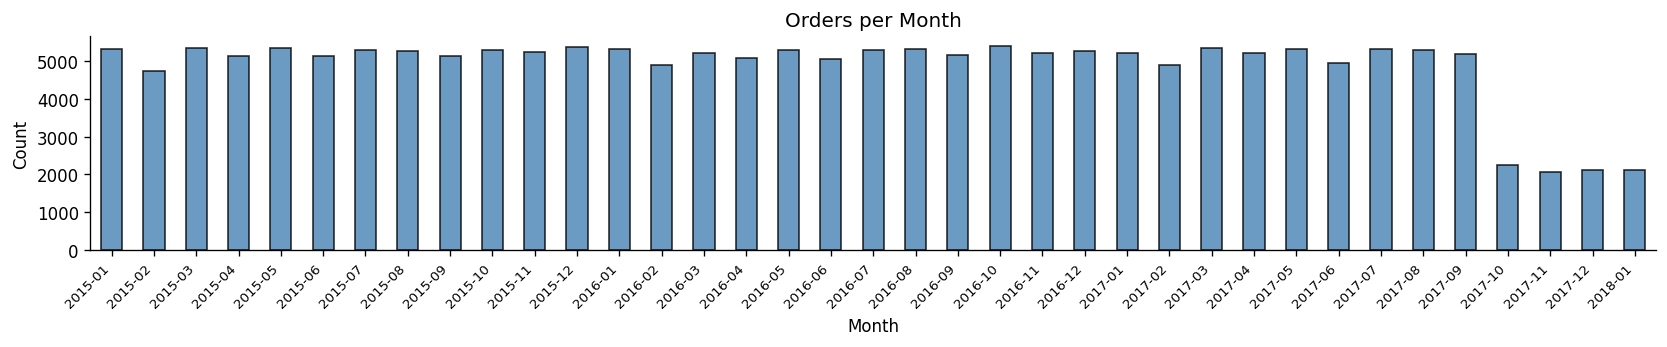

In [10]:
print(f"Date range: {df_raw[DATE_COL].min()} → {df_raw[DATE_COL].max()}")
print(f"Span: {(df_raw[DATE_COL].max() - df_raw[DATE_COL].min()).days} days")

per_month = df_raw.groupby(df_raw[DATE_COL].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(14, 3))
per_month.plot(kind="bar", ax=ax, color="steelblue", edgecolor="k", alpha=0.8)
ax.set_title("Orders per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Correlation Heatmap (Numeric Features + Target)

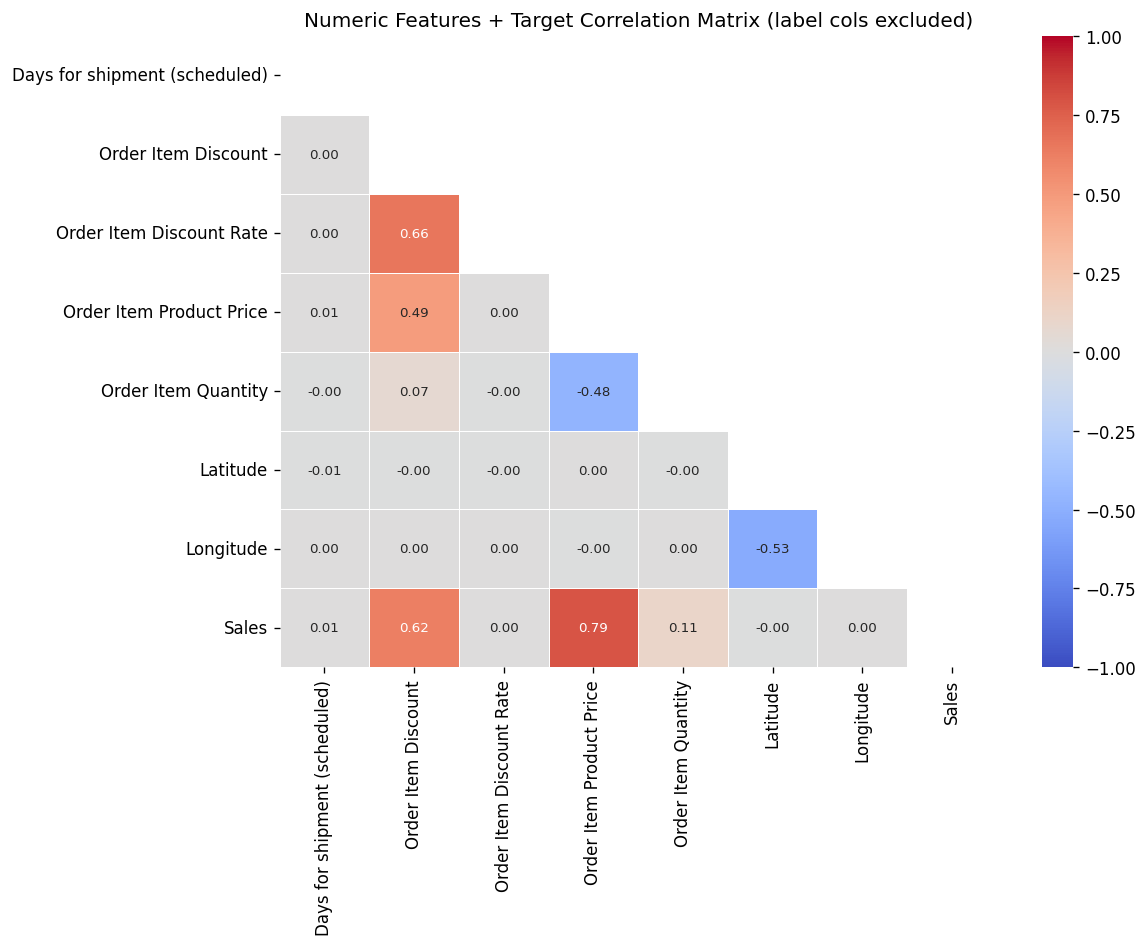


Correlation with Sales:
Order Item Product Price         0.789948
Order Item Discount              0.617438
Order Item Quantity              0.106442
Days for shipment (scheduled)    0.006327
Longitude                        0.001696
Latitude                        -0.000696
Order Item Discount Rate         0.000346


In [11]:
corr_cols = FEATURE_COLS + [TARGET_COL]
corr = df_raw[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 8}, linewidths=0.3)
ax.set_title("Numeric Features + Target Correlation Matrix (label cols excluded)")
plt.tight_layout()
plt.show()

target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print(f"\nCorrelation with {TARGET_COL}:")
print(target_corr.to_string())

---
## 9. Feature Engineering\n\nWe add:
- **Temporal** features from `order date (DateOrders)`: hour, day_of_week, month, quarter
- **One-hot encoded** categoricals: Type, Shipping Mode, Customer Segment, Market, Delivery Status, Department Name (25 dummies total with drop_first=True)
- **Lag features** of Sales: lag1, lag2, rolling3 mean (all via `.shift(1)` — no leakage)

In [12]:
df_eng = engineer_features(df_raw)
new_cols = [c for c in df_eng.columns if c not in df_raw.columns]
print(f"Shape before : {df_raw.shape}")
print(f"Shape after  : {df_eng.shape}")
print(f"\nNew columns ({len(new_cols)}):")
temporal = [c for c in new_cols if c.startswith("order_")]
one_hot  = [c for c in new_cols if "__" in c]
lag_cols = [c for c in new_cols if "lag" in c or "rolling" in c]
print(f"  Temporal ({len(temporal)}) : {temporal}")
print(f"  One-hot  ({len(one_hot)}) : {one_hot}")
print(f"  Lags     ({len(lag_cols)}) : {lag_cols}")
df_eng[[TARGET_COL, "lag1_target", "lag2_target", "rolling3_mean_target"]].head(6)

Shape before : (180519, 53)
Shape after  : (180517, 79)

New columns (32):
  Temporal (4) : ['order_hour', 'order_day_of_week', 'order_month', 'order_quarter']
  One-hot  (25) : ['Type__DEBIT', 'Type__PAYMENT', 'Type__TRANSFER', 'Shipping Mode__Same Day', 'Shipping Mode__Second Class', 'Shipping Mode__Standard Class', 'Customer Segment__Corporate', 'Customer Segment__Home Office', 'Market__Europe', 'Market__LATAM', 'Market__Pacific Asia', 'Market__USCA', 'Delivery Status__Late delivery', 'Delivery Status__Shipping canceled', 'Delivery Status__Shipping on time', 'Department Name__Book Shop', 'Department Name__Discs Shop', 'Department Name__Fan Shop', 'Department Name__Fitness', 'Department Name__Footwear', 'Department Name__Golf', 'Department Name__Health and Beauty ', 'Department Name__Outdoors', 'Department Name__Pet Shop', 'Department Name__Technology']
  Lags     (3) : ['lag1_target', 'lag2_target', 'rolling3_mean_target']


,Sales,lag1_target,lag2_target,rolling3_mean_target
0,250.000000,199.990005,299.980011,249.985008
1,129.990005,250.000000,199.990005,249.990005
2,199.919998,129.990005,250.000000,193.326670
3,150.000000,199.919998,129.990005,193.303335
4,49.980000,150.000000,199.919998,159.970001
5,299.950012,49.980000,150.000000,133.299999


---
## 10. Lag Feature Leakage Check

In [13]:
print("First 6 rows — lag1_target[i] must equal Sales[i-1]:")
print(df_eng[[TARGET_COL, "lag1_target", "lag2_target"]].head(6).to_string())

assert np.isclose(df_eng["lag1_target"].iloc[1], df_eng[TARGET_COL].iloc[0], rtol=1e-9), \
    "LAG LEAKAGE DETECTED"
print("\n✓ Lag leakage check PASSED")

First 6 rows — lag1_target[i] must equal Sales[i-1]:
        Sales  lag1_target  lag2_target
0  250.000000   199.990005   299.980011
1  129.990005   250.000000   199.990005
2  199.919998   129.990005   250.000000
3  150.000000   199.919998   129.990005
4   49.980000   150.000000   199.919998
5  299.950012    49.980000   150.000000

✓ Lag leakage check PASSED


In [14]:
X, y, feature_names = build_design_matrix(df_eng)
print(f"X: {X.shape}   y: {y.shape}")
print(f"\nFeatures ({len(feature_names)}):")
for i, name in enumerate(feature_names):
    print(f"  {i:2d}: {name}")

X: (180517, 39)   y: (180517,)

Features (39):
   0: Days for shipment (scheduled)
   1: Latitude
   2: Longitude
   3: Order Item Discount
   4: Order Item Discount Rate
   5: Order Item Product Price
   6: Order Item Quantity
   7: order_hour
   8: order_day_of_week
   9: order_month
  10: order_quarter
  11: Type__DEBIT
  12: Type__PAYMENT
  13: Type__TRANSFER
  14: Shipping Mode__Same Day
  15: Shipping Mode__Second Class
  16: Shipping Mode__Standard Class
  17: Customer Segment__Corporate
  18: Customer Segment__Home Office
  19: Market__Europe
  20: Market__LATAM
  21: Market__Pacific Asia
  22: Market__USCA
  23: Delivery Status__Late delivery
  24: Delivery Status__Shipping canceled
  25: Delivery Status__Shipping on time
  26: Department Name__Book Shop
  27: Department Name__Discs Shop
  28: Department Name__Fan Shop
  29: Department Name__Fitness
  30: Department Name__Footwear
  31: Department Name__Golf
  32: Department Name__Health and Beauty 
  33: Department Name__Outd

In [15]:
leaked = [c for c in feature_names if c in LABEL_COLS]
assert len(leaked) == 0, f"Label columns in X: {leaked}"
assert TARGET_COL not in feature_names
print("✓ Label exclusion check PASSED")

print(f"Any NaN in X : {np.isnan(X).any()}")
print(f"Any Inf in X : {np.isinf(X).any()}")
print(f"y range: [${y.min():.2f}, ${y.max():.2f}]  mean=${y.mean():.2f}  std=${y.std():.2f}")

✓ Label exclusion check PASSED
Any NaN in X : False
Any Inf in X : False
y range: [$9.99, $1999.99]  mean=$203.77  std=$132.27


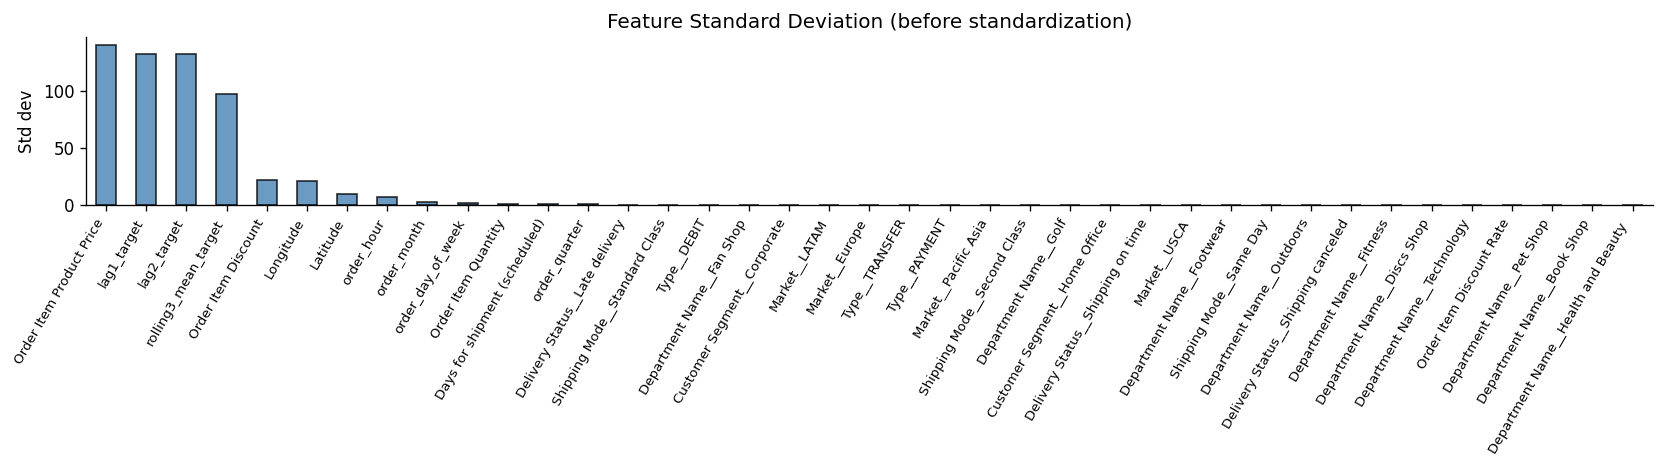

Near-zero variance: None


In [16]:
std_s = pd.Series(X.std(axis=0), index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
std_s.plot(kind="bar", ax=ax, color="steelblue", edgecolor="k", alpha=0.8)
ax.set_title("Feature Standard Deviation (before standardization)")
ax.set_ylabel("Std dev")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

near_zero = std_s[std_s < 1e-6]
print("Near-zero variance:", near_zero.to_dict() if len(near_zero) else "None")

---
## 12. Save Processed Arrays

In [17]:
os.makedirs(DATA_DIR, exist_ok=True)
np.save(os.path.join(DATA_DIR, "X_processed.npy"), X)
np.save(os.path.join(DATA_DIR, "y_processed.npy"), y)
np.save(os.path.join(DATA_DIR, "feature_names.npy"), np.array(feature_names, dtype=object))

print(f"Saved to {DATA_DIR}/")
print(f"  X_processed.npy   {X.shape}")
print(f"  y_processed.npy   {y.shape}")
print(f"  feature_names.npy {len(feature_names)} names")

Saved to /Users/sarthakgarg/Desktop/UMD/MSML604/Project/msml604-convex-regression/notebooks/../data/
  X_processed.npy   (180517, 39)
  y_processed.npy   (180517,)
  feature_names.npy 39 names


---
## 13. Summary

| Item | Value |
|---|---|
| Dataset | DataCo Smart Supply Chain for Big Data Analysis (Kaggle), 180,519 rows |
| Raw numeric features | 7: `Days for shipment (scheduled)`, `Order Item Discount`, `Order Item Discount Rate`, `Order Item Product Price`, `Order Item Quantity`, `Latitude`, `Longitude` |
| One-hot categorical features | Type (3), Shipping Mode (3), Customer Segment (2), Market (4), Delivery Status (3), Department Name (10) = **25 dummies** |
| Temporal features | `order_hour`, `order_day_of_week`, `order_month`, `order_quarter` |
| Lag features | `lag1_target`, `lag2_target`, `rolling3_mean_target` |
| Total features in X | **39** |
| Target | `Sales` (USD, $9.99–$1,999.99, mean $203.77, skew=2.88) |
| Excluded (leakage) | `Order Item Total` (r=0.99), `Sales per customer` (r=0.99), `Benefit per order`, `Order Profit Per Order`, `Order Item Profit Ratio` |
| Duplicate excluded | `Product Price` (= `Order Item Product Price` exactly) |
| Leakage prevention | Lags use `.shift(1)` ✓; label cols excluded ✓ |
| Key correlations | `Order Item Product Price` r=0.79, `Order Item Discount` r=0.62, `rolling3_mean_target` r=0.42 |

**Next**: Run `02_real_experiments.ipynb`.